In [43]:
import json
import os

import numpy as np
import pandas as pd

# Plot the accuracy

dir = '../data/results/experiments/main_experiment_19'

results_df = pd.read_csv(os.path.join(dir, 'results.csv')).drop(columns=['Unnamed: 0'])

results_means_df = pd.read_csv(os.path.join(dir, 'results_means.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

print(f"""
RUNTIMES

MEANS = {results_means_df['error'].mean()}
BASE = {results_df['error'].mean()}
""")

results_df.groupby('pci_beam_config')['error'].mean()


RUNTIMES

MEANS = 20.34490784170339
BASE = 20.346055670064324



pci_beam_config
0.0    42.369442
1.0    13.671824
2.0     4.996901
Name: error, dtype: float64

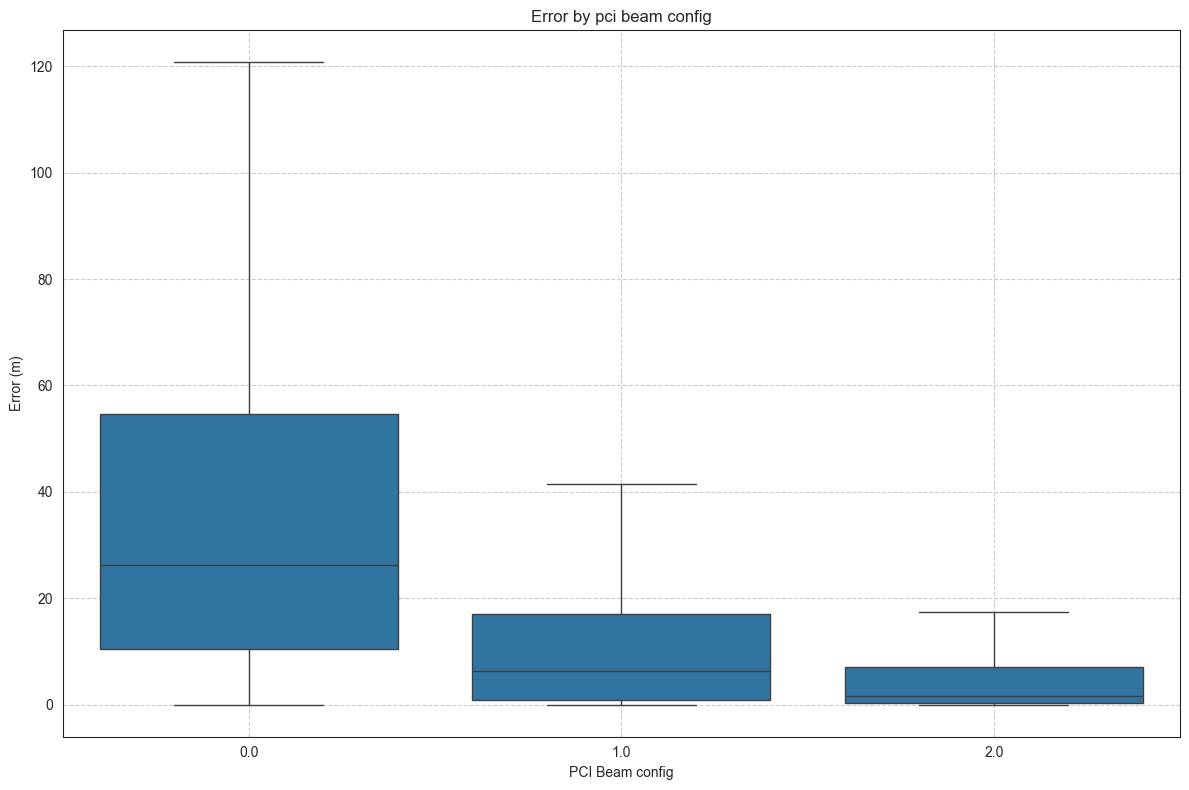

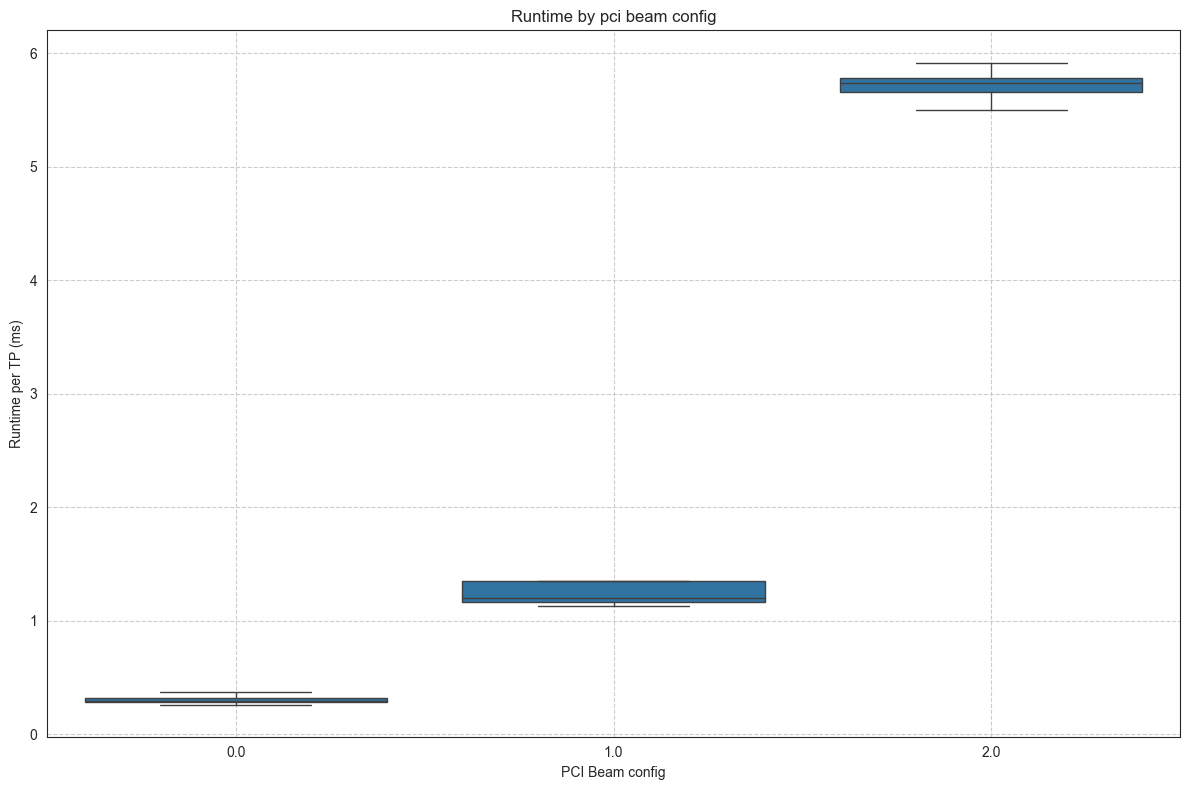

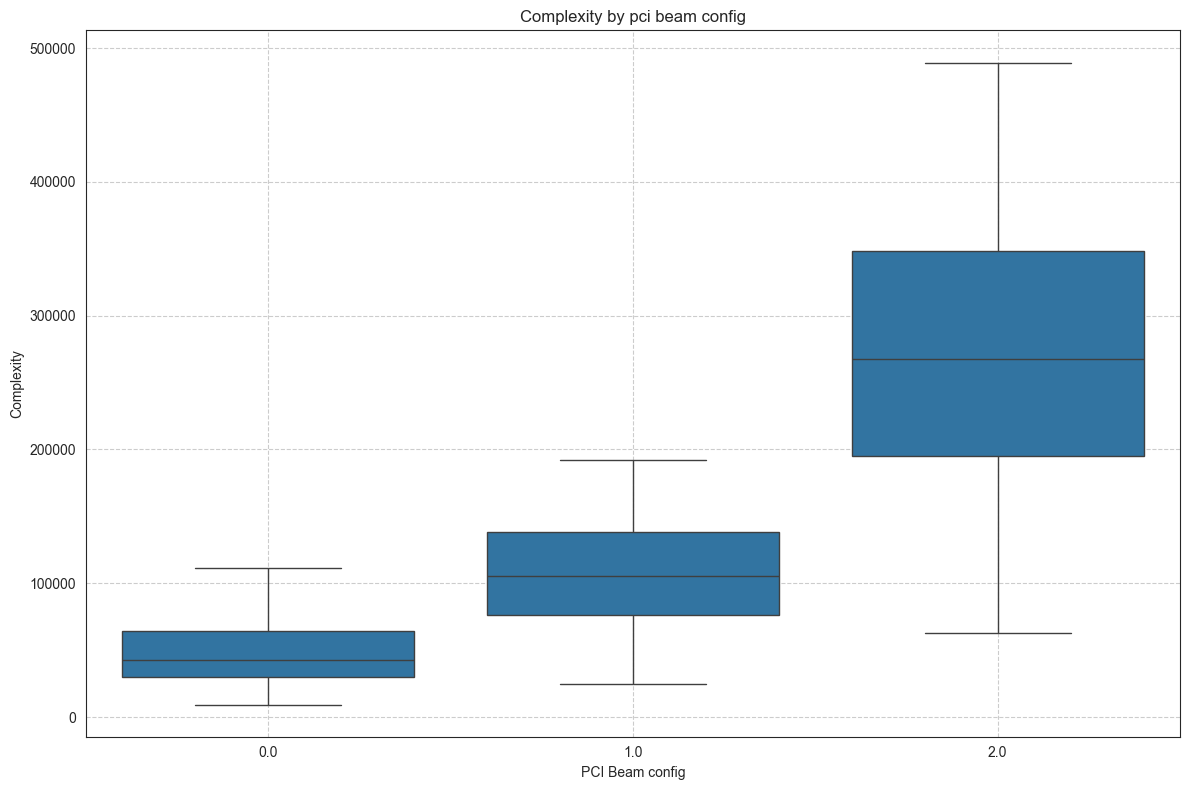

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt


def plot(df: pd.DataFrame, x: str, y: str, x_label: str, y_label: str, title: str):
    plt.figure(figsize=(12, 8))

    sns.set_style("white")
    sns.boxplot(y=y, x=x, data=df, showfliers=False)

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(linestyle='--')
    plt.tight_layout()
    plt.show()


plot(results_df, x='pci_beam_config', y='error', x_label='PCI Beam config', y_label='Error (m)',
     title='Error by pci beam config')

plot(results_df, x='pci_beam_config', y='runtime', x_label='PCI Beam config', y_label='Runtime per TP (ms)',
     title='Runtime by pci beam config')

plot(results_df, x='pci_beam_config', y='complexity', x_label='PCI Beam config', y_label='Complexity',
     title='Complexity by pci beam config')

/var/folders/sz/wsd2tvj51v1c7jpt5gscdckc0000gn/T/ipykernel_3703/1802113772.py:35: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


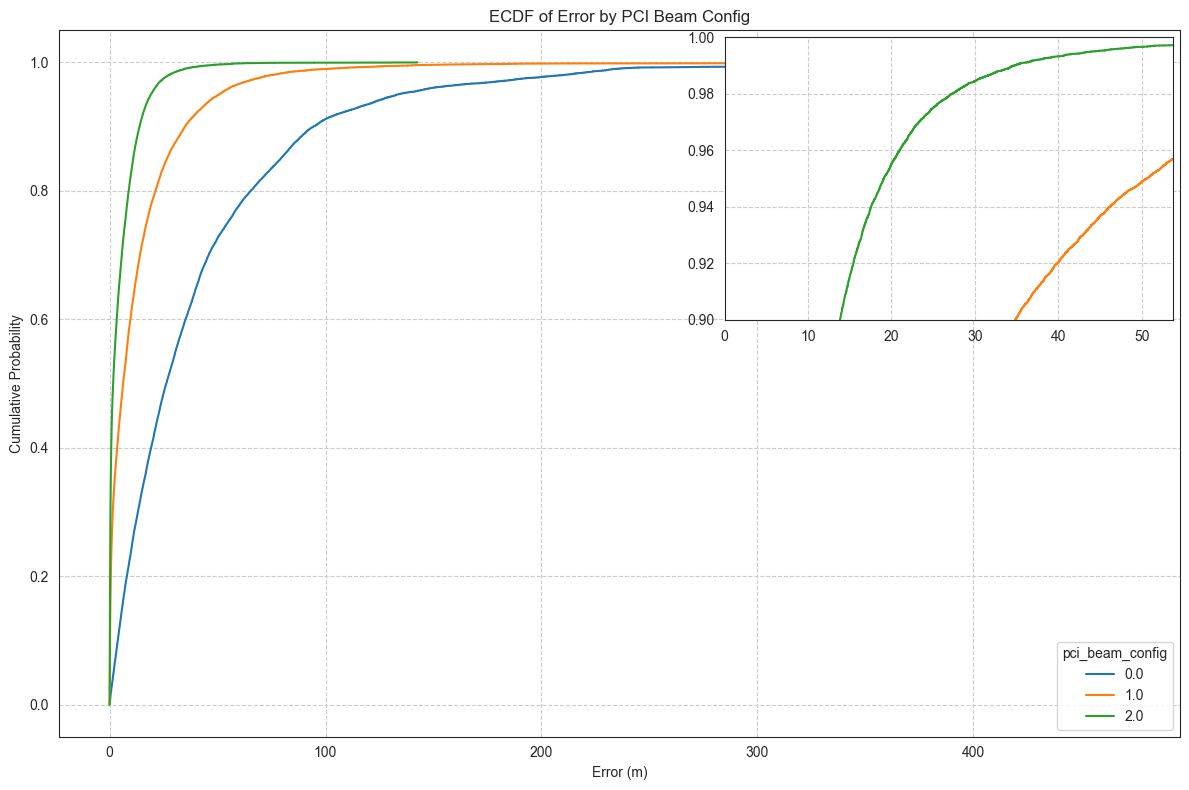

In [45]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def plot_ecdf(df: pd.DataFrame, x: str, hue: str, x_label: str, y_label: str, title: str):
    fig, ax = plt.subplots(figsize=(12, 8))

    unique_configs = df[hue].unique()

    for config in unique_configs:
        data = df[df[hue] == config][x]
        x_values = np.sort(data)
        y_values = np.arange(1, len(x_values) + 1) / len(x_values)
        ax.step(x_values, y_values, where='post', label=f'{config}')

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid(linestyle='--')
    ax.legend(title=hue)

    # Create inset for zoomed-in section
    ax_inset = inset_axes(ax, width="40%", height="40%", loc='upper right')

    for config in unique_configs:
        data = df[df[hue] == config][x]
        x_values = np.sort(data)
        y_values = np.arange(1, len(x_values) + 1) / len(x_values)
        ax_inset.step(x_values, y_values, where='post', label=f'{config}')

    # Set limits for the inset to focus on the top 90th percentile
    ax_inset.set_xlim(0, np.percentile(df[x], 90))
    ax_inset.set_ylim(0.9, 1.0)
    ax_inset.grid(linestyle='--')

    plt.tight_layout()
    plt.show()


# Plotting ECDFs for different PCI beam configurations
plot_ecdf(results_df, x='error', hue='pci_beam_config', x_label='Error (m)', y_label='Cumulative Probability',
          title='ECDF of Error by PCI Beam Config')
